In [1]:
# ── 0. Environment check ─────────────────────────────────────────────────────
# This notebook now runs both locally and in Colab. Mount Drive only when Colab
# is actually available.
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception:
    print('Not running in Colab; using local project files.')


Not running in Colab; using local project files.


In [2]:
# ── 1. Install, imports, paths & config ──────────────────────────────────────
# If a package is missing, uncomment and run this line once:
# !pip install librosa torch torchvision -q

import os, json, random, time
from pathlib import Path

import librosa
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tv_models
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


def find_project_root():
    """Find the folder containing audio/ and train_phon_transcripts.jsonl."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    candidates += [
        Path('/content'),
        Path('/content/drive/MyDrive'),
        Path('/content/drive/MyDrive/final'),
        Path('/content/drive/MyDrive/MLPR/Project/phonetic-speech-recognition-children/final'),
    ]

    for root in candidates:
        if (root / 'audio').exists() and (root / 'train_phon_transcripts.jsonl').exists():
            return root

    # Last resort: search common Colab Drive locations, but keep it bounded.
    for base in [Path('/content/drive/MyDrive'), Path('/content')]:
        if not base.exists():
            continue
        for labels_path in base.rglob('train_phon_transcripts.jsonl'):
            root = labels_path.parent
            if (root / 'audio').exists():
                return root

    raise FileNotFoundError(
        'Could not find project root. Put this notebook in the folder that contains '
        'audio/ and train_phon_transcripts.jsonl, or update PROJECT_ROOT manually.'
    )


PROJECT_ROOT = find_project_root()
AUDIO_DIR = PROJECT_ROOT / 'audio'
LABELS_JSON = PROJECT_ROOT / 'train_phon_transcripts.jsonl'

SAMPLE_RATE = 16000
N_MFCC = 40
BATCH_SIZE = 8      # VGG frontend is heavier than plain BiLSTM
EPOCHS = 50
LR = 1e-3
STATUS_EVERY_BATCHES = 25
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Project root: {PROJECT_ROOT}')
print(f'Audio dir:    {AUDIO_DIR}')
print(f'Labels:       {LABELS_JSON}')
print(f'Device:       {DEVICE}')


Project root: /home/rgcodes/Programming/MLPR/Project/phonetic-speech-recognition-children/final
Audio dir:    /home/rgcodes/Programming/MLPR/Project/phonetic-speech-recognition-children/final/audio
Labels:       /home/rgcodes/Programming/MLPR/Project/phonetic-speech-recognition-children/final/train_phon_transcripts.jsonl
Device:       cuda


In [3]:
# ── 2. Load labels ───────────────────────────────────────────────────────────
def split_phones(text):
    phones, i = [], 0
    while i < len(text):
        if i + 1 < len(text) and text[i + 1] == 'ː':
            phones.append(text[i:i+2])
            i += 2
        elif text[i] != ' ':
            phones.append(text[i])
            i += 1
        else:
            i += 1
    return ' '.join(phones)


def load_jsonl(path):
    mapping = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            r = json.loads(line)
            mapping[r['utterance_id'] + '.flac'] = split_phones(r['phonetic_text'])
    return mapping


labels_dict = load_jsonl(LABELS_JSON)

all_phones = {p for v in labels_dict.values() for p in v.split()}
vocab = ['<blank>'] + sorted(all_phones)
phone2idx = {p: i for i, p in enumerate(vocab)}
idx2phone = {i: p for p, i in phone2idx.items()}
NUM_CLASSES = len(vocab)
print(f'Vocab: {NUM_CLASSES} | Utterances: {len(labels_dict)} | Device: {DEVICE}')

# Deterministic train/val split so metrics are reproducible.
items = list(labels_dict.items())
random.shuffle(items)
split = int(0.9 * len(items))
train_dict = dict(items[:split])
val_dict = dict(items[split:])
print(f'Train: {len(train_dict)} | Val: {len(val_dict)}')


Vocab: 83 | Utterances: 12043 | Device: cuda
Train: 10838 | Val: 1205


In [4]:
# ── 3. Shared MFCC helpers ───────────────────────────────────────────────────

def safe_delta(mfcc):
    w = min(9, mfcc.shape[1])
    if w % 2 == 0:
        w -= 1
    return librosa.feature.delta(mfcc, width=max(w, 3))


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BENCHMARK B — pretrained VGG-style CNN frontend + BiLSTM + CTC
# ══════════════════════════════════════════════════════════════════════════════
# The earlier notebook tried to feed raw waveforms directly into torchvggish.
# That fails because torchvggish.forward expects precomputed log-mel image
# patches, not a 1D waveform. Here we use ImageNet-pretrained VGG11-BN conv
# weights as a transfer CNN over MFCC/delta/delta images and preserve the time
# axis for CTC.

class VGGFrameDataset(Dataset):
    def __init__(self, d):
        self.items = list(d.items())

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        fname, phone_str = self.items[idx]
        y, _ = librosa.load(AUDIO_DIR / fname, sr=SAMPLE_RATE)
        mfcc = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
        feat = np.vstack([mfcc, safe_delta(mfcc), safe_delta(safe_delta(mfcc))]).T
        feat = (feat - feat.mean(0)) / (feat.std(0) + 1e-8)
        label = torch.LongTensor([phone2idx[p] for p in phone_str.split() if p in phone2idx])
        return torch.FloatTensor(feat), label


def collate_vgg(batch):
    feats, labels = zip(*batch)
    return (
        pad_sequence(feats, batch_first=True),
        torch.cat(labels),
        torch.LongTensor([f.shape[0] for f in feats]),
        torch.LongTensor([l.shape[0] for l in labels]),
    )


vtrain_dl = DataLoader(VGGFrameDataset(train_dict), BATCH_SIZE, shuffle=True, collate_fn=collate_vgg)
vval_dl = DataLoader(VGGFrameDataset(val_dict), BATCH_SIZE, shuffle=False, collate_fn=collate_vgg)


class VGGFrontendBiLSTM(nn.Module):
    def __init__(self, n_cls=NUM_CLASSES, hidden=256, lstm_layers=2, freeze_vgg=True):
        super().__init__()
        try:
            weights = tv_models.VGG11_BN_Weights.DEFAULT
            vgg = tv_models.vgg11_bn(weights=weights)
            print('Loaded ImageNet-pretrained VGG11-BN weights.')
        except Exception as exc:
            print(f'Could not load pretrained VGG weights ({exc}); using random VGG11-BN init.')
            vgg = tv_models.vgg11_bn(weights=None)

        layers = []
        for layer in vgg.features:
            if isinstance(layer, nn.MaxPool2d):
                # Reduce frequency resolution but preserve time resolution for CTC.
                layers.append(nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)))
            else:
                layers.append(layer)
        self.vgg_features = nn.Sequential(*layers)

        if freeze_vgg:
            for p in self.vgg_features.parameters():
                p.requires_grad = False

        self.lstm = nn.LSTM(512, hidden, lstm_layers, batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Linear(hidden * 2, n_cls)

    def forward(self, feats):
        # feats: (B, T, 120) = MFCC + delta + delta-delta.
        bsz, time_steps, feat_dim = feats.shape
        if feat_dim != 3 * N_MFCC:
            raise ValueError(f'Expected feature dim {3 * N_MFCC}, got {feat_dim}')

        x = feats.view(bsz, time_steps, 3, N_MFCC).permute(0, 2, 3, 1).contiguous()
        # x: (B, 3, freq=40, time=T). VGG pools frequency only, so time stays T.
        x = self.vgg_features(x)
        # x: (B, 512, reduced_freq, T). Average frequency -> sequence over time.
        x = x.mean(dim=2).transpose(1, 2).contiguous()
        x, _ = self.lstm(x)
        return self.fc(x)


In [6]:
# ── Train pretrained VGG frontend + BiLSTM with CER tracking ─────────────────

def greedy_ctc_decode(logits, blank_idx=0):
    # logits: (B, T, C)
    pred = logits.argmax(dim=-1).detach().cpu().numpy()
    decoded = []
    for seq in pred:
        out = []
        prev = blank_idx
        for idx in seq:
            idx = int(idx)
            if idx != blank_idx and idx != prev:
                out.append(idx)
            prev = idx
        decoded.append(out)
    return decoded


def ids_to_phone_string(ids):
    return ' '.join(idx2phone[i] for i in ids if i in idx2phone)


def cer(reference, hypothesis):
    # CER over IPA characters, ignoring spaces between phoneme tokens.
    ref = reference.replace(' ', '')
    hyp = hypothesis.replace(' ', '')
    m, n = len(ref), len(hyp)
    prev = list(range(n + 1))
    for i in range(1, m + 1):
        curr = [i] + [0] * n
        for j in range(1, n + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return prev[n] / max(1, m)


def batch_cer(logits, labels, label_lens):
    pred_ids_batch = greedy_ctc_decode(logits, blank_idx=0)
    labels_cpu = labels.detach().cpu()
    label_lens_cpu = label_lens.detach().cpu()

    scores = []
    offset = 0
    for pred_ids, target_len in zip(pred_ids_batch, label_lens_cpu):
        target_len = int(target_len)
        target_ids = labels_cpu[offset:offset + target_len].tolist()
        offset += target_len
        ref = ids_to_phone_string(target_ids)
        hyp = ids_to_phone_string(pred_ids)
        scores.append(cer(ref, hyp))
    return scores


def gpu_status():
    if DEVICE != 'cuda':
        return 'cpu'
    used = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    return f'gpu_mem={used:.2f}G allocated/{reserved:.2f}G reserved'


def format_eta(elapsed, done, total):
    if done <= 0:
        return 'eta=?'
    seconds = elapsed * max(0, total - done) / done
    mins, secs = divmod(int(seconds), 60)
    return f'eta={mins:02d}:{secs:02d}'


def train_vgg_model(model, train_dl, val_dl):
    ctc = nn.CTCLoss(blank=0, zero_infinity=True)
    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

    best_val_loss = float('inf')
    best_train_cer = float('inf')
    best_val_cer = float('inf')
    history = []

    print(
        f'[vgg] starting run | epochs={EPOCHS} | train_batches={len(train_dl)} | '
        f'val_batches={len(val_dl)} | batch_size={BATCH_SIZE} | device={DEVICE}',
        flush=True,
    )

    for ep in range(1, EPOCHS + 1):
        epoch_start = time.time()
        model.train()
        if hasattr(model, 'vgg_features'):
            model.vgg_features.eval()  # keep frozen VGG batchnorm stable

        print(f'[vgg] Ep {ep:02d}/{EPOCHS} train start | {gpu_status()}', flush=True)
        train_loss = 0.0
        train_cers = []
        for batch_idx, (feats, labels, feat_lens, label_lens) in enumerate(train_dl, start=1):
            feats = feats.to(DEVICE)
            labels = labels.to(DEVICE)
            feat_lens = feat_lens.to(DEVICE)
            label_lens = label_lens.to(DEVICE)

            logits = model(feats)
            out_lens = torch.clamp(feat_lens, max=logits.size(1))
            lp = logits.log_softmax(-1).permute(1, 0, 2)
            loss = ctc(lp, labels, out_lens, label_lens)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), 5.0)
            opt.step()

            train_loss += loss.item()
            train_cers.extend(batch_cer(logits, labels, label_lens))

            if batch_idx == 1 or batch_idx % STATUS_EVERY_BATCHES == 0 or batch_idx == len(train_dl):
                elapsed = time.time() - epoch_start
                running_loss = train_loss / batch_idx
                running_cer = float(np.mean(train_cers)) if train_cers else 1.0
                print(
                    f'[vgg] Ep {ep:02d}/{EPOCHS} train '
                    f'batch {batch_idx:04d}/{len(train_dl)} | '
                    f'loss={running_loss:.4f} | cer={running_cer:.4f} | '
                    f'{format_eta(elapsed, batch_idx, len(train_dl))} | {gpu_status()}',
                    flush=True,
                )

        model.eval()
        print(f'[vgg] Ep {ep:02d}/{EPOCHS} val start', flush=True)
        val_start = time.time()
        val_loss = 0.0
        val_cers = []
        with torch.no_grad():
            for batch_idx, (feats, labels, feat_lens, label_lens) in enumerate(val_dl, start=1):
                feats = feats.to(DEVICE)
                labels = labels.to(DEVICE)
                feat_lens = feat_lens.to(DEVICE)
                label_lens = label_lens.to(DEVICE)

                logits = model(feats)
                out_lens = torch.clamp(feat_lens, max=logits.size(1))
                lp = logits.log_softmax(-1).permute(1, 0, 2)
                val_loss += ctc(lp, labels, out_lens, label_lens).item()
                val_cers.extend(batch_cer(logits, labels, label_lens))

                if batch_idx == 1 or batch_idx % STATUS_EVERY_BATCHES == 0 or batch_idx == len(val_dl):
                    elapsed = time.time() - val_start
                    running_loss = val_loss / batch_idx
                    running_cer = float(np.mean(val_cers)) if val_cers else 1.0
                    print(
                        f'[vgg] Ep {ep:02d}/{EPOCHS} val '
                        f'batch {batch_idx:04d}/{len(val_dl)} | '
                        f'loss={running_loss:.4f} | cer={running_cer:.4f} | '
                        f'{format_eta(elapsed, batch_idx, len(val_dl))}',
                        flush=True,
                    )

        train_loss /= len(train_dl)
        val_loss /= len(val_dl)
        train_cer = float(np.mean(train_cers)) if train_cers else 1.0
        val_cer = float(np.mean(val_cers)) if val_cers else 1.0
        sch.step(val_loss)

        best_train_cer = min(best_train_cer, train_cer)
        best_val_cer = min(best_val_cer, val_cer)
        history.append({
            'epoch': ep,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_cer': train_cer,
            'val_cer': val_cer,
            'best_train_cer': best_train_cer,
            'best_val_cer': best_val_cer,
        })

        history_path = PROJECT_ROOT / 'results' / 'vgg_training_history.json'
        history_path.parent.mkdir(parents=True, exist_ok=True)
        history_path.write_text(json.dumps(history, indent=2))

        print(
            f'[vgg] Ep {ep:02d} done | '
            f'Train loss {train_loss:.4f} | Val loss {val_loss:.4f} | '
            f'Train CER {train_cer:.4f} | Val CER {val_cer:.4f} | '
            f'Best train CER {best_train_cer:.4f} | Best val CER {best_val_cer:.4f}',
            flush=True,
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    'model_state': model.state_dict(),
                    'epoch': ep,
                    'best_val_loss': best_val_loss,
                    'train_cer': train_cer,
                    'val_cer': val_cer,
                    'best_train_cer': best_train_cer,
                    'best_val_cer': best_val_cer,
                    'history': history,
                    'vocab': vocab,
                },
                PROJECT_ROOT / 'best_vgg.pt',
            )
            print(f'  saved best val-loss checkpoint (val={val_loss:.4f})', flush=True)

    return best_val_loss, best_train_cer, best_val_cer, history


vgg_model = VGGFrontendBiLSTM().to(DEVICE)
best_vgg_loss, best_vgg_train_cer, best_vgg_val_cer, vgg_history = train_vgg_model(vgg_model, vtrain_dl, vval_dl)

print('\nBenchmark Summary')
print(f'VGG frontend + BiLSTM best val loss:  {best_vgg_loss:.4f}')
print(f'VGG frontend + BiLSTM best train CER: {best_vgg_train_cer:.4f}')
print(f'VGG frontend + BiLSTM best val CER:   {best_vgg_val_cer:.4f}')


Downloading: "https://download.pytorch.org/models/vgg11_bn-6002323d.pth" to /home/rgcodes/.cache/torch/hub/checkpoints/vgg11_bn-6002323d.pth


100%|██████████| 507M/507M [00:33<00:00, 15.6MB/s] 


Loaded ImageNet-pretrained VGG11-BN weights.
[vgg] starting run | epochs=50 | train_batches=1355 | val_batches=151 | batch_size=8 | device=cuda
[vgg] Ep 01/50 train start | gpu_mem=0.05G allocated/0.06G reserved


/home/rgcodes/anaconda3/envs/mlbasic/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[vgg] Ep 01/50 train batch 0001/1355 | loss=47.8420 | cer=4.4458 | eta=49:10 | gpu_mem=0.10G allocated/0.28G reserved
[vgg] Ep 01/50 train batch 0025/1355 | loss=10.0326 | cer=1.1378 | eta=03:50 | gpu_mem=0.10G allocated/0.46G reserved
[vgg] Ep 01/50 train batch 0050/1355 | loss=7.0984 | cer=1.0689 | eta=02:42 | gpu_mem=0.10G allocated/0.46G reserved
[vgg] Ep 01/50 train batch 0075/1355 | loss=6.0876 | cer=1.0459 | eta=02:15 | gpu_mem=0.10G allocated/0.46G reserved
[vgg] Ep 01/50 train batch 0100/1355 | loss=5.5844 | cer=1.0345 | eta=02:03 | gpu_mem=0.10G allocated/0.72G reserved
[vgg] Ep 01/50 train batch 0125/1355 | loss=5.2763 | cer=1.0276 | eta=01:51 | gpu_mem=0.10G allocated/0.72G reserved
[vgg] Ep 01/50 train batch 0150/1355 | loss=5.0603 | cer=1.0230 | eta=01:44 | gpu_mem=0.10G allocated/0.72G reserved
[vgg] Ep 01/50 train batch 0175/1355 | loss=4.9113 | cer=1.0197 | eta=01:38 | gpu_mem=0.10G allocated/0.72G reserved
[vgg] Ep 01/50 train batch 0200/1355 | loss=4.7823 | cer=1.017

## VGG Training Plots

Run these cells after the VGG training cell finishes. They plot the training/validation loss, CER, and generalization gap so the VGG experiment can be documented clearly.


In [7]:
# ── VGG plot setup: collect history from memory or checkpoint ────────────────
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PLOTS_DIR = PROJECT_ROOT / 'results' / 'vgg_plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

if 'vgg_history' in globals() and len(vgg_history) > 0:
    history_records = vgg_history
    history_source = 'in-memory vgg_history from this notebook run'
else:
    history_json = PROJECT_ROOT / 'results' / 'vgg_training_history.json'
    checkpoint_path = PROJECT_ROOT / 'best_vgg.pt'
    if history_json.exists():
        history_records = json.loads(history_json.read_text())
        history_source = str(history_json)
    elif checkpoint_path.exists():
        ckpt = torch.load(checkpoint_path, map_location='cpu')
        history_records = ckpt.get('history', [])
        history_source = str(checkpoint_path)
    else:
        raise RuntimeError('No VGG history found yet. Run the VGG training cell first.')

vgg_df = pd.DataFrame(history_records).sort_values('epoch').reset_index(drop=True)
vgg_df['gap_cer'] = vgg_df['val_cer'] - vgg_df['train_cer']
vgg_df['best_val_cer_so_far'] = vgg_df['val_cer'].cummin()
vgg_df['best_train_cer_so_far'] = vgg_df['train_cer'].cummin()

csv_path = PLOTS_DIR / 'vgg_training_history.csv'
vgg_df.to_csv(csv_path, index=False)

print(f'Loaded {len(vgg_df)} VGG epochs from {history_source}')
print(f'Saved history table to: {csv_path}')
display(vgg_df.tail(10))


Loaded 50 VGG epochs from in-memory vgg_history from this notebook run
Saved history table to: /home/rgcodes/Programming/MLPR/Project/phonetic-speech-recognition-children/final/results/vgg_plots/vgg_training_history.csv


,epoch,train_loss,val_loss,train_cer,val_cer,best_train_cer,best_val_cer,gap_cer,best_val_cer_so_far,best_train_cer_so_far
40,41,1.466620,5.174286,0.413771,0.915958,0.413771,0.901199,0.502187,0.901199,0.413771
41,42,1.465827,5.178663,0.412651,0.915540,0.412651,0.901199,0.502889,0.901199,0.412651
42,43,1.463589,5.179676,0.412388,0.915797,0.412388,0.901199,0.503409,0.901199,0.412388
43,44,1.461584,5.182591,0.411355,0.915208,0.411355,0.901199,0.503853,0.901199,0.411355
44,45,1.462025,5.181070,0.411216,0.914732,0.411216,0.901199,0.503516,0.901199,0.411216
45,46,1.461411,5.182956,0.410818,0.914530,0.410818,0.901199,0.503712,0.901199,0.410818
46,47,1.461211,5.184691,0.411389,0.915034,0.410818,0.901199,0.503645,0.901199,0.410818
47,48,1.460863,5.184402,0.409956,0.913921,0.409956,0.901199,0.503966,0.901199,0.409956
48,49,1.461350,5.186102,0.410722,0.914913,0.409956,0.901199,0.504190,0.901199,0.409956
49,50,1.458512,5.186100,0.410833,0.915609,0.409956,0.901199,0.504775,0.901199,0.409956


Saved plot to: /home/rgcodes/Programming/MLPR/Project/phonetic-speech-recognition-children/final/results/vgg_plots/vgg_loss_cer_curves.png


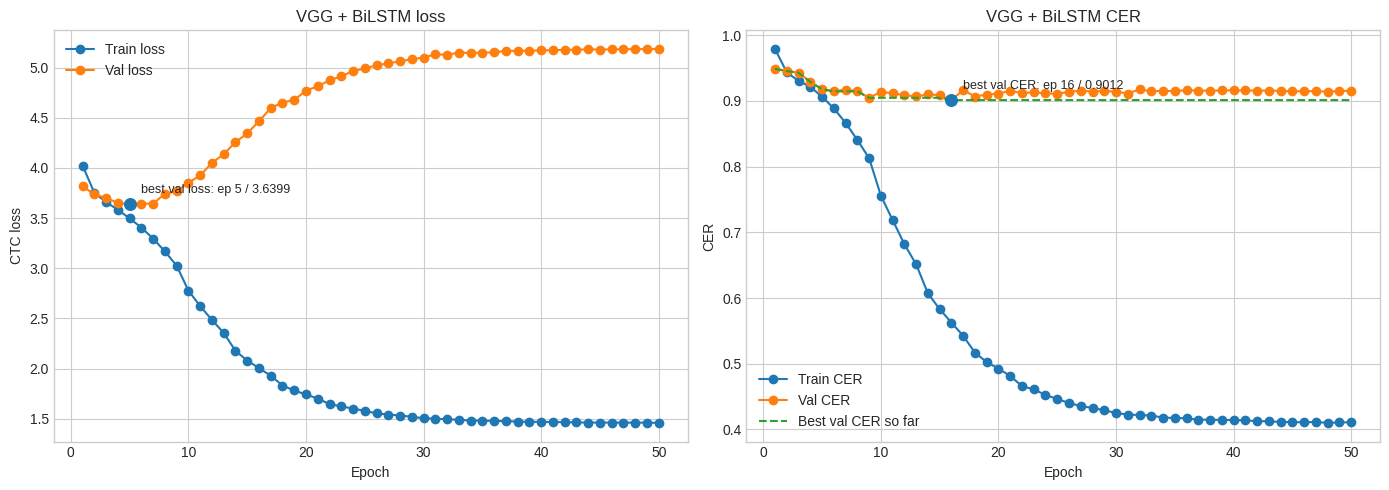

In [8]:
# ── Plot VGG loss and CER curves ────────────────────────────────────────────
def mark_best(ax, df, metric, label):
    best_idx = df[metric].idxmin()
    row = df.loc[best_idx]
    ax.scatter([row['epoch']], [row[metric]], s=70, zorder=5)
    ax.annotate(
        f'{label}: ep {int(row["epoch"])} / {row[metric]:.4f}',
        xy=(row['epoch'], row[metric]),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=9,
    )

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(vgg_df['epoch'], vgg_df['train_loss'], marker='o', label='Train loss')
axes[0].plot(vgg_df['epoch'], vgg_df['val_loss'], marker='o', label='Val loss')
mark_best(axes[0], vgg_df, 'val_loss', 'best val loss')
axes[0].set_title('VGG + BiLSTM loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CTC loss')
axes[0].legend()

axes[1].plot(vgg_df['epoch'], vgg_df['train_cer'], marker='o', label='Train CER')
axes[1].plot(vgg_df['epoch'], vgg_df['val_cer'], marker='o', label='Val CER')
axes[1].plot(vgg_df['epoch'], vgg_df['best_val_cer_so_far'], linestyle='--', label='Best val CER so far')
mark_best(axes[1], vgg_df, 'val_cer', 'best val CER')
axes[1].set_title('VGG + BiLSTM CER')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CER')
axes[1].legend()

fig.tight_layout()
out_path = PLOTS_DIR / 'vgg_loss_cer_curves.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight')
print(f'Saved plot to: {out_path}')
plt.show()


Saved plot to: /home/rgcodes/Programming/MLPR/Project/phonetic-speech-recognition-children/final/results/vgg_plots/vgg_generalization_gap.png


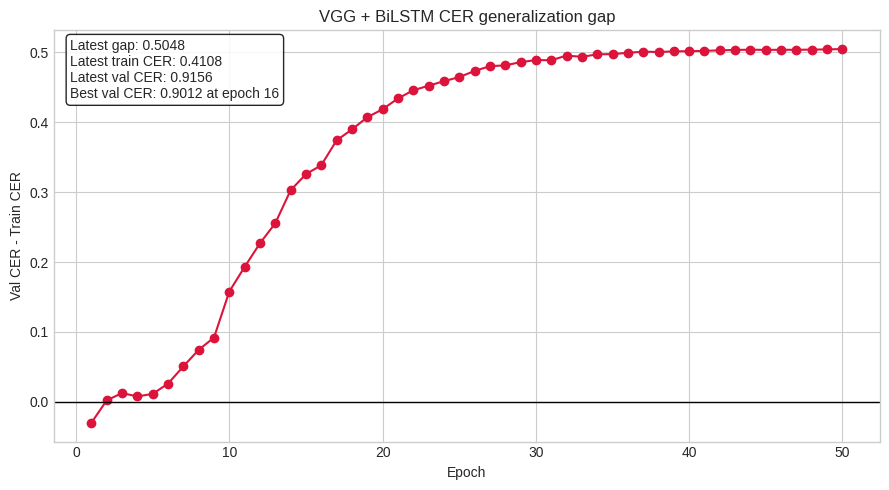

In [9]:
# ── Plot overfitting/generalization gap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(vgg_df['epoch'], vgg_df['gap_cer'], marker='o', color='crimson')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('VGG + BiLSTM CER generalization gap')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val CER - Train CER')

latest = vgg_df.iloc[-1]
best_val = vgg_df.loc[vgg_df['val_cer'].idxmin()]
summary = (
    f'Latest gap: {latest["gap_cer"]:.4f}\n'
    f'Latest train CER: {latest["train_cer"]:.4f}\n'
    f'Latest val CER: {latest["val_cer"]:.4f}\n'
    f'Best val CER: {best_val["val_cer"]:.4f} at epoch {int(best_val["epoch"])}'
)
ax.text(
    0.02,
    0.98,
    summary,
    transform=ax.transAxes,
    va='top',
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85},
)

fig.tight_layout()
out_path = PLOTS_DIR / 'vgg_generalization_gap.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight')
print(f'Saved plot to: {out_path}')
plt.show()


In [10]:
# ── Optional: plot VGG phoneme-level errors if a report exists ───────────────
# First generate the report, if needed, from a terminal:
# python scripts/evaluate_vgg_bilstm.py --checkpoint best_vgg.pt --manifest data/manifests/test.jsonl --out results/vgg_bilstm_test_predictions.jsonl

candidate_reports = [
    PROJECT_ROOT / 'results' / 'vgg_bilstm_test_predictions.phoneme_report.json',
    PROJECT_ROOT / 'results' / 'vgg_bilstm_test_predictions_phoneme_report.json',
]
report_path = next((p for p in candidate_reports if p.exists()), None)

if report_path is None:
    print('No VGG phoneme report found yet. Run scripts/evaluate_vgg_bilstm.py after training to create one.')
else:
    report = json.loads(report_path.read_text())
    rows = report.get('phoneme_error_rates', report.get('phoneme_stats', []))
    ph_df = pd.DataFrame(rows)
    if ph_df.empty:
        print(f'Found {report_path}, but it did not contain phoneme rows.')
    else:
        # Normalize common report schemas.
        phoneme_col = 'phoneme' if 'phoneme' in ph_df.columns else ph_df.columns[0]
        rate_col = next((c for c in ['error_rate', 'per', 'phoneme_error_rate'] if c in ph_df.columns), None)
        count_col = next((c for c in ['ref_count', 'count', 'support'] if c in ph_df.columns), None)
        if rate_col is None:
            raise RuntimeError(f'Could not find an error-rate column in {report_path}. Columns: {list(ph_df.columns)}')
        if count_col is not None:
            ph_df = ph_df[ph_df[count_col] >= 5]
        ph_df = ph_df.sort_values(rate_col, ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(ph_df[phoneme_col].astype(str), ph_df[rate_col])
        ax.invert_yaxis()
        ax.set_title('VGG worst phonemes by error rate')
        ax.set_xlabel('Error rate')
        ax.set_ylabel('Phoneme')
        fig.tight_layout()
        out_path = PLOTS_DIR / 'vgg_worst_phonemes.png'
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
        print(f'Saved plot to: {out_path}')
        display(ph_df)
        plt.show()


No VGG phoneme report found yet. Run scripts/evaluate_vgg_bilstm.py after training to create one.
